# Project Echo — Socio-Economic Income Predictor (IPUMS CPS Edition)

**Regression** model that predicts an individual's **total personal income (`INCTOT`)**
from socio-economic, demographic, work, education, geographic, and disability factors.

This notebook is a *modernization* of the original ACS-based model: the data source has been
switched from `fairlearn.datasets.fetch_acs_income` to a local **IPUMS CPS ASEC 2022** extract
(`cps_00001.dat`) described by the DDI codebook `cps_00001.xml`. The `.dat` file is a
fixed-width text file; the codebook supplies each variable's column positions and value codes.

The model is an **ensemble of XGBoost, LightGBM, and CatBoost regressors** trained on
`log1p(INCTOT)` and averaged at inference time; predictions are returned to dollar scale via `expm1()`.

The notebook follows the 12-stage structure of `ML_Model_Building_Template.md`:
Setup → Load/Preview → Clean → EDA → Feature Engineering → Split → Scaling →
Model Selection → Training → Learning Curves → Evaluation → Save & Inference.

## Stage 1 — Environment Setup & Library Imports

Import everything needed for loading, preprocessing, visualization, modelling, and evaluation,
and set pandas/numpy display options so exploratory output is not truncated.
No internet dataset loader is required — the CPS extract is read from disk.

In [114]:
# Install Dependencies (run once): boosting libraries + parquet engine
# IPUMS data is local, so no fairlearn/folktables loader is needed.
#!pip install scikit-learn
#!pip install xgboost
#!pip install lightgbm
#!pip install catboost
#!pip install seaborn
#!pip install fastparquet

In [115]:
# Import Core Libraries: numpy, pandas, matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Display options (template Stage 1) - keep exploratory output fully visible
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
np.set_printoptions(threshold=10000)

In [116]:
# Import Preprocessing Tools: scalers, transformers, encoders, imputer
from sklearn.preprocessing import QuantileTransformer, StandardScaler, MinMaxScaler, Normalizer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import KNNImputer

In [117]:
# Import Algorithms: regression models for baseline comparison
# Ridge, Lasso: L2/L1 regularized linear models
# XGBoost, LightGBM, CatBoost: gradient boosting ensemble models (#)
from sklearn.linear_model import (
    LinearRegression,
    Ridge,  #
    Lasso,  #
    ElasticNet,
    SGDRegressor,
    BayesianRidge,
    ARDRegression
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,  #
    ExtraTreesRegressor,
    GradientBoostingRegressor
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor  #
from lightgbm import LGBMRegressor  #
from catboost import CatBoostRegressor  #

In [118]:
# Import Evaluation & Selection Tools: cross-validation, metrics, feature selection
from sklearn.model_selection import cross_val_predict, train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
    explained_variance_score
)
import seaborn as sbn
from sklearn.feature_selection import SelectKBest, mutual_info_regression, f_regression
from sklearn.model_selection import StratifiedShuffleSplit, ShuffleSplit

In [119]:
# Import Boosting Libraries: native xgboost and lightgbm for callbacks and early stopping
import xgboost as xgb
import lightgbm as lgb

## Stage 2 — Data Loading & Textual Preview

IPUMS distributes the data as a **fixed-width** file (`cps_00001.dat`). The DDI codebook
(`cps_00001.xml`) defines, for every variable, its start/end character position and width.
We rebuild that column layout here and load the extract with `pd.read_fwf`, then inspect the
schema, dtypes, and the distribution of the target (`INCTOT`).

In [120]:
# Load Dataset: parse the IPUMS CPS fixed-width file using the column layout from the DDI codebook
# P1: INCTOT uses sentinel codes (999999999 = N.I.U., 999999998 = Missing) that must be removed.
# Each (StartPos, EndPos) pair below is taken directly from cps_00001.xml (1-indexed, inclusive).
column_spec = {
    'YEAR':      (1, 4),    'SERIAL':   (5, 9),     'MONTH':    (10, 11),
    'CPSID':     (12, 25),  'ASECFLAG': (26, 26),   'ASECWTH':  (27, 37),
    'REGION':    (38, 39),  'STATEFIP': (40, 41),   'METRO':    (42, 42),
    'PERNUM':    (43, 44),  'CPSIDP':   (45, 58),   'CPSIDV':   (59, 73),
    'ASECWT':    (74, 84),  'AGE':      (85, 86),   'SEX':      (87, 87),
    'RACE':      (88, 90),  'MARST':    (91, 91),   'NCHILD':   (92, 92),
    'CITIZEN':   (93, 93),  'NATIVITY': (94, 94),   'HISPAN':   (95, 97),
    'EMPSTAT':   (98, 99),  'OCC':      (100, 103), 'IND':      (104, 107),
    'CLASSWKR':  (108, 109),'UHRSWORKT':(110, 112), 'UHRSWORK1':(113, 115),
    'EDUC':      (116, 118),'FULLPART': (119, 119), 'INCTOT':   (120, 128),
    'DISABWRK':  (129, 129),'UNION':    (130, 130),
}
names = list(column_spec)
colspecs = [(start - 1, end) for start, end in column_spec.values()]  # 0-indexed, half-open for read_fwf

income_df = pd.read_fwf("cps_00001.dat", colspecs=colspecs, names=names, dtype="Int64")

print(income_df.head())
print(income_df.tail())
# DDI guarantees fixed-width numeric fields -> no parse NaNs; "missingness" is encoded as sentinel values.
print(income_df.info())

   YEAR  SERIAL  MONTH           CPSID  ASECFLAG   ASECWTH  REGION  STATEFIP  METRO  PERNUM          CPSIDP           CPSIDV    ASECWT  AGE  SEX  RACE  MARST  NCHILD  CITIZEN  NATIVITY  HISPAN  EMPSTAT   OCC   IND  CLASSWKR  UHRSWORKT  UHRSWORK1  EDUC  FULLPART  INCTOT  DISABWRK  UNION
0  2022       1      3  20210102744400         1  25531300      11        23      1       1  20210102744401  202101027444011  25531300   42    1   100      6       0        1         1       0       10  2805  6670        21         48         40    91         1   44220         1      0
1  2022       5      3  20211202723000         1  15868000      11        23      1       1  20211202723001  202112027230011  15868000   62    1   100      1       0        1         1       0       10   440   770        13         28         28    73         2   32702         1      0
2  2022       5      3  20211202723000         1  15868000      11        23      1       2  20211202723002  202112027230021  15868000   64

In [121]:
# Textual: Preview target 'INCTOT' (Total personal income) before any cleaning
# P1: sentinel codes inflate the range; they are not real dollar values.
print("INCTOT raw describe:")
print(income_df['INCTOT'].describe())
print()
print("N.I.U.   (999999999):", (income_df['INCTOT'] == 999999999).sum())
print("Missing  (999999998):", (income_df['INCTOT'] == 999999998).sum())
print("Negative (< 0):      ", (income_df['INCTOT'] < 0).sum())
print("Zero     (== 0):     ", (income_df['INCTOT'] == 0).sum())

INCTOT raw describe:
count            152732.0
mean      207023184.28368
std      405124618.596894
min               -9999.0
25%               15000.0
50%               45239.5
75%             150350.25
max           999999999.0
Name: INCTOT, dtype: Float64

N.I.U.   (999999999): 31613
Missing  (999999998): 0
Negative (< 0):       109
Zero     (== 0):      14476


## Stage 3 — Data Cleaning & Problem Fixing

Resolve data-quality problems before encoding. Order matters: define the modelling population
and target first, then handle missing values, then encode categoricals.

**Identified problems**
- **P1 — Target sentinels / scope.** `INCTOT` carries `999999999` (N.I.U.) and `999999998` (Missing)
  codes, plus zeros/negatives. `INCTOT` is *prior-year* income, so current-job attributes are only
  meaningful for people who are currently working. We therefore restrict to **employed earners**
  (`EMPSTAT` 10/12) aged 16+ with a real positive income.
- **P2 — Skewed target with a heavy right tail** (handled later via a `log1p` target transform).
- **P3 — Coded categoricals** (`RACE`, `MARST`, `CLASSWKR`, `EDUC`, `OCC`) need grouping into
  readable, model-friendly categories.
- **Missing values** — `UHRSWORKT` uses `997` (hours vary) / `999` (N.I.U.); recoded to `NaN` and
  KNN-imputed (template Stage 3a).

In [122]:
# Fix P1: Restrict to the modelling population and drop INCTOT sentinel codes
# Universe: employed earners (EMPSTAT 10 = At work, 12 = Has job, not at work) aged 16+ with INCTOT > 0.
income_df = income_df[income_df['INCTOT'] < 999999998]   # drop N.I.U. (999999999) and Missing (999999998)
income_df = income_df[income_df['INCTOT'] > 0]            # keep real positive income (log1p-safe)
income_df = income_df[income_df['AGE'] >= 16]             # working age
income_df = income_df[income_df['EMPSTAT'].isin([10, 12])]  # currently employed -> valid OCC/CLASSWKR/hours

# Drop identifier / weight / redundant technical columns that carry no predictive signal.
drop_cols = ['YEAR', 'SERIAL', 'MONTH', 'CPSID', 'ASECFLAG', 'ASECWTH', 'PERNUM',
             'CPSIDP', 'CPSIDV', 'ASECWT', 'EMPSTAT', 'CITIZEN', 'IND', 'UHRSWORK1', 'REGION', 'HISPAN']
income_df = income_df.drop(columns=drop_cols)
income_df = income_df.astype('int64')

print("Population after cleaning:", income_df.shape)
print(income_df.head())

Population after cleaning: (69785, 16)
   STATEFIP  METRO  AGE  SEX  RACE  MARST  NCHILD  NATIVITY   OCC  CLASSWKR  UHRSWORKT  EDUC  FULLPART  INCTOT  DISABWRK  UNION
0        23      1   42    1   100      6       0         1  2805        21         48    91         1   44220         1      0
1        23      1   62    1   100      1       0         1   440        13         28    73         2   32702         1      0
2        23      1   64    2   100      1       0         1  2014        27         40   111         1   50050         1      2
3        23      1   26    1   100      1       0         1  4710        21         50    81         1   40001         1      0
4        23      1   24    2   300      1       0         1  2014        21         40    81         1   20000         2      0


50th percentile: $50,001
75th percentile: $84,013
90th percentile: $140,002
95th percentile: $196,177
99th percentile: $410,058
99.9th percentile: $1,105,154


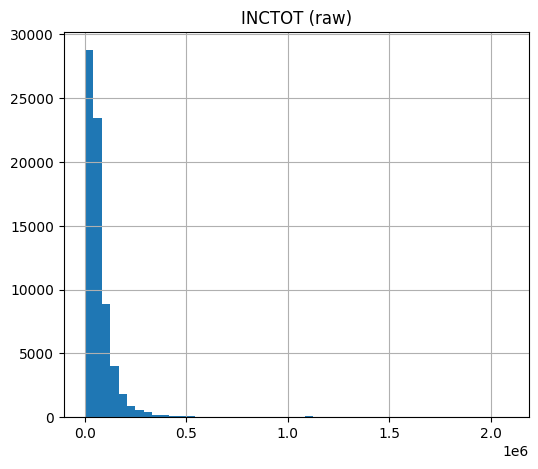

In [123]:
# Graphical: Preview dataset 1 - Analyze outliers in target 'INCTOT'
# P2: INCTOT is heavily right-skewed with a small number of very high-income outliers.
for p in [50, 75, 90, 95, 99, 99.9]:
    print(f"{p}th percentile: ${np.percentile(income_df['INCTOT'], p):,.0f}")

income_df['INCTOT'].hist(figsize=(6, 5), bins=50)
plt.title("INCTOT (raw)")
plt.show()

In [124]:
# Preprocessing 1: Create working copy of dataset for cleaning / outlier treatment
income_df_rm_out = income_df.copy()

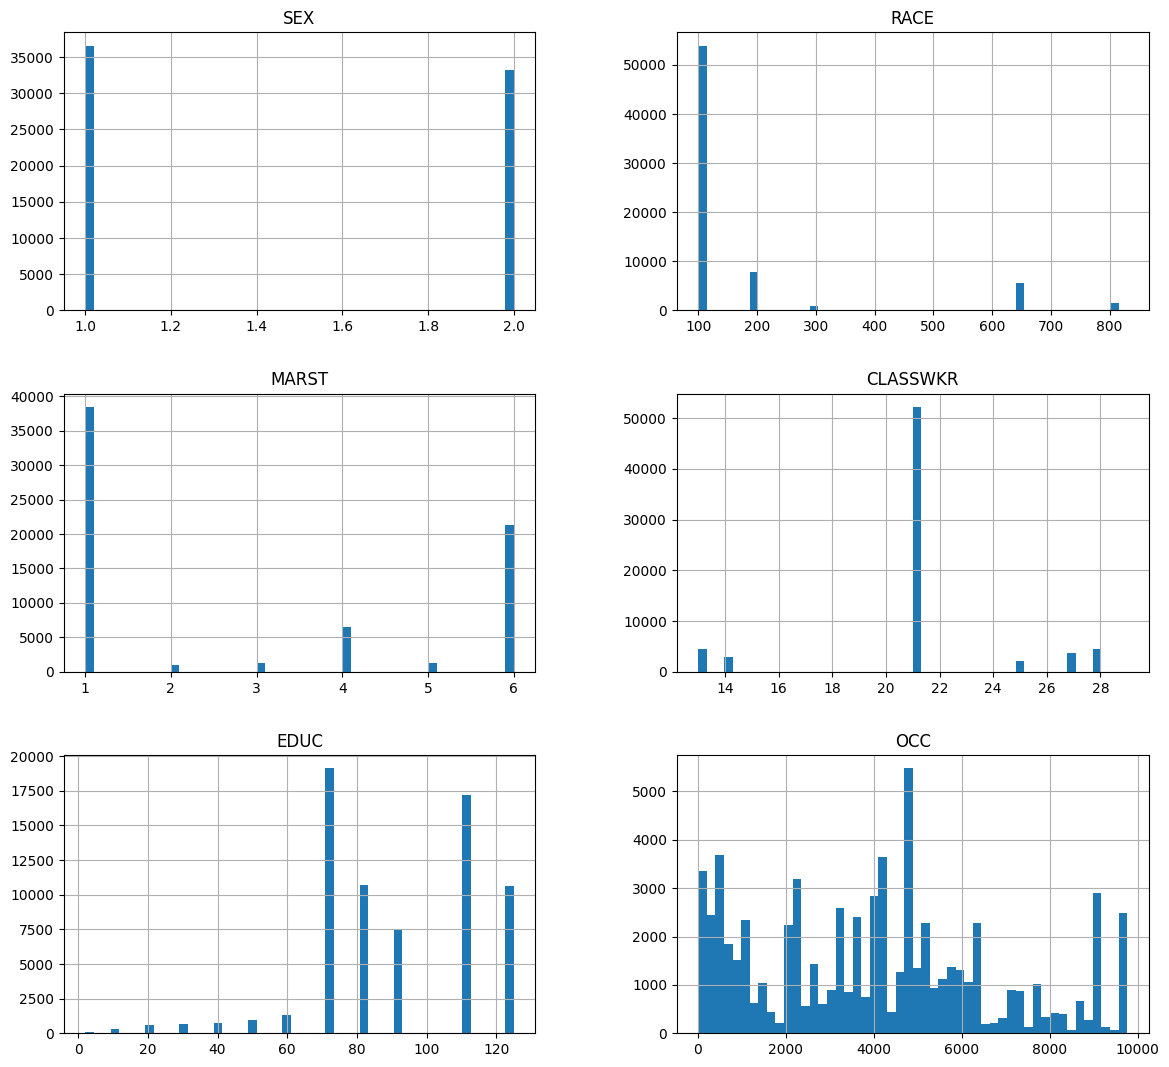

In [125]:
# Graphical: Preview dataset 2 - Class imbalance across coded categorical features
# P3: SEX, RACE, MARST, CLASSWKR, EDUC, OCC show uneven class distributions.
cols = ['SEX', 'RACE', 'MARST', 'CLASSWKR', 'EDUC', 'OCC']

income_df[cols].hist(bins=50, figsize=(14, 13))
plt.show()

In [126]:
# Textual: Preview dataset 2 - Confirm working copy and inspect INCTOT distribution
print(income_df_rm_out.head())
print(income_df_rm_out.tail())
print(income_df_rm_out['INCTOT'].describe())

   STATEFIP  METRO  AGE  SEX  RACE  MARST  NCHILD  NATIVITY   OCC  CLASSWKR  UHRSWORKT  EDUC  FULLPART  INCTOT  DISABWRK  UNION
0        23      1   42    1   100      6       0         1  2805        21         48    91         1   44220         1      0
1        23      1   62    1   100      1       0         1   440        13         28    73         2   32702         1      0
2        23      1   64    2   100      1       0         1  2014        27         40   111         1   50050         1      2
3        23      1   26    1   100      1       0         1  4710        21         50    81         1   40001         1      0
4        23      1   24    2   300      1       0         1  2014        21         40    81         1   20000         2      0
        STATEFIP  METRO  AGE  SEX  RACE  MARST  NCHILD  NATIVITY   OCC  CLASSWKR  UHRSWORKT  EDUC  FULLPART  INCTOT  DISABWRK  UNION
152722        15      2   26    1   651      6       0         1  4760        21        997    73  

### Stage 3a — Missing Values (KNN Imputation)

CPS encodes "no usable answer" with sentinel codes rather than blanks. For `UHRSWORKT`
(usual hours worked per week), `997` = *hours vary* and `999` = *N.I.U.* We recode these to
`NaN` and impute them with `KNNImputer`, using `AGE` and `EDUC` as neighbour features.

In [127]:
# Fix (Missing Values): UHRSWORKT sentinels 997 / 999 -> NaN, then KNN-impute (template Stage 3a)
# Handle missing values BEFORE categorical encoding so they are not treated as their own category.
income_df_rm_out['UHRSWORKT'] = income_df_rm_out['UHRSWORKT'].replace({997: np.nan, 999: np.nan})
print("UHRSWORKT missing before impute:", income_df_rm_out['UHRSWORKT'].isna().sum())

knn_imputer = KNNImputer(n_neighbors=5)
income_df_rm_out[['AGE', 'UHRSWORKT', 'EDUC']] = knn_imputer.fit_transform(
    income_df_rm_out[['AGE', 'UHRSWORKT', 'EDUC']]
)
# UHRSWORKT is a whole-hours count; restore integer scale after imputation.
income_df_rm_out['UHRSWORKT'] = income_df_rm_out['UHRSWORKT'].round().astype(int)
income_df_rm_out['AGE'] = income_df_rm_out['AGE'].round().astype(int)
income_df_rm_out['EDUC'] = income_df_rm_out['EDUC'].round().astype(int)

print("UHRSWORKT missing after impute: ", income_df_rm_out['UHRSWORKT'].isna().sum())

UHRSWORKT missing before impute: 4339
UHRSWORKT missing after impute:  0


### Stage 3c — Class Imbalance

The template's oversampling/undersampling step (SMOTE / RandomUnderSampler) targets *classification*
imbalance and does **not** apply to this **regression** task. The analogous problem here is the
right-skewed continuous target, which we address with the `log1p` transform in Stage 7 rather than
by resampling rows.

In [128]:
# Preprocessing 2: Create second working copy for group-level categorical encoding
income_df_rm_out_group = income_df_rm_out.copy()

In [129]:
# Textual: Preview SEX feature distribution
print(income_df_rm_out_group['SEX'].value_counts())

SEX
1    36605
2    33180
Name: count, dtype: int64


In [130]:
# Textual: Preview CLASSWKR (Class of worker) feature distribution
print(income_df_rm_out['CLASSWKR'].value_counts())

CLASSWKR
21    52178
28     4582
13     4430
27     3634
14     2851
25     2088
29       22
Name: count, dtype: int64


### Stage 3b — Categorical Grouping & Encoding

Collapse high-cardinality / sparsely-populated codes into readable groups, mirroring the
`map_*` helpers of the original notebook but using the IPUMS CPS code definitions from `cps_00001.xml`.

In [131]:
# Fix P3a: Group RACE (CPS race codes) into readable string categories
# CPS RACE codes -> 'white', 'black', 'asian', 'indigenous', 'pacific', 'other', 'multi'
def map_race(x):
    if x == 100:
        return "white"
    elif x == 200:
        return "black"
    elif x in [650, 651]:
        return "asian"
    elif x == 300:
        return "indigenous"     # American Indian / Aleut / Eskimo
    elif x == 652:
        return "pacific"        # Hawaiian / Pacific Islander only
    elif x == 700:
        return "other"          # Other single race, n.e.c.
    elif 801 <= x <= 830:
        return "multi"          # Two or more races
    else:
        return "unknown"

income_df_rm_out_group["RACE_GROUP"] = income_df_rm_out["RACE"].apply(map_race)
income_df_rm_out = income_df_rm_out.dropna(subset=['RACE'])
income_df_rm_out_group = income_df_rm_out_group.dropna(subset=['RACE_GROUP'])

print(income_df_rm_out['RACE'].value_counts())
print(income_df_rm_out_group['RACE_GROUP'].value_counts())

income_df_rm_out_group.drop('RACE', axis=1, inplace=True)

RACE
100    53937
200     7814
651     5088
300      939
802      445
652      440
801      415
803      326
809       73
804       68
805       53
813       47
810       33
806       24
811       19
812       13
808       10
830        9
816        7
807        6
817        6
814        4
819        3
815        3
820        2
818        1
Name: count, dtype: int64
RACE_GROUP
white         53937
black          7814
asian          5088
multi          1567
indigenous      939
pacific         440
Name: count, dtype: int64


In [132]:
# Fix P3b: Group CLASSWKR (class-of-worker codes) into employment-sector categories
# CLASSWKR codes -> 'self_employed', 'private', 'nonprofit', 'government', 'armed_forces', 'unpaid'
def map_classwkr(x):
    if x in [10, 13, 14]:
        return "self_employed"
    elif x in [21, 22]:
        return "private"            # private, for profit
    elif x == 23:
        return "nonprofit"          # private, nonprofit
    elif x in [24, 25, 27, 28]:
        return "government"         # federal / state / local
    elif x == 26:
        return "armed_forces"
    elif x == 29:
        return "unpaid"             # unpaid family worker
    else:
        return "unknown"

income_df_rm_out_group["CLASSWKR_GROUP"] = income_df_rm_out["CLASSWKR"].apply(map_classwkr)
income_df_rm_out = income_df_rm_out.dropna(subset=['CLASSWKR'])
income_df_rm_out_group = income_df_rm_out_group.dropna(subset=['CLASSWKR_GROUP'])

print(income_df_rm_out['CLASSWKR'].value_counts())
print(income_df_rm_out_group['CLASSWKR_GROUP'].value_counts())

income_df_rm_out_group.drop('CLASSWKR', axis=1, inplace=True)

CLASSWKR
21    52178
28     4582
13     4430
27     3634
14     2851
25     2088
29       22
Name: count, dtype: int64
CLASSWKR_GROUP
private          52178
government       10304
self_employed     7281
unpaid              22
Name: count, dtype: int64


In [133]:
# Fix P3c: Group EDUC (educational attainment codes 2-125) into 6 ordinal education tiers
# 1=Less than HS, 2=HS/GED, 3=Some college, 4=Associate, 5=Bachelor, 6=Graduate+
def map_educ(s):
    if s <= 72:
        return 1.0   # Less than HS diploma (incl. 12th grade, no diploma)
    elif s == 73:
        return 2.0   # HS diploma or equivalent (GED)
    elif s in [80, 81, 90, 100]:
        return 3.0   # Some college, no degree
    elif s in [91, 92]:
        return 4.0   # Associate's degree
    elif s in [110, 111]:
        return 5.0   # Bachelor's degree
    elif 120 <= s <= 125:
        return 6.0   # Graduate / professional degree
    else:
        return 1.0   # default to lowest tier

print(income_df_rm_out['EDUC'].value_counts().sort_index())
income_df_rm_out_group['EDUC'] = income_df_rm_out['EDUC'].apply(map_educ)
print(income_df_rm_out_group['EDUC'].value_counts())

EDUC
2         94
10       283
20       633
30       647
40       707
50       945
60      1337
71       886
73     18228
81     10678
91      3226
92      4236
111    17226
123     7763
124     1198
125     1698
Name: count, dtype: int64
EDUC
2.0    18228
5.0    17226
3.0    10678
6.0    10659
4.0     7462
1.0     5532
Name: count, dtype: int64


In [134]:
# Fix P3d: Group OCC (occupation codes) into 25 industry-standard abbreviations
# CPS uses the Census occupation classification; the same broad code ranges as the original model apply.
# e.g. MGR=Management, ENG=Engineering, MED=Medical, TRN=Transportation, MIL=Military
import numpy as np
import pandas as pd

def map_occ_group(code):
    if pd.isna(code):
        return np.nan

    code = int(code)

    if 10 <= code <= 440:
        return "MGR"
    elif 500 <= code <= 750:
        return "BUS"
    elif 800 <= code <= 960:
        return "FIN"
    elif 1005 <= code <= 1240:
        return "CMM"
    elif 1305 <= code <= 1560:
        return "ENG"
    elif 1600 <= code <= 1980:
        return "SCI"
    elif 2001 <= code <= 2060:
        return "CMS"
    elif 2100 <= code <= 2180:
        return "LGL"
    elif 2205 <= code <= 2555:
        return "EDU"
    elif 2600 <= code <= 2920:
        return "ENT"
    elif 3000 <= code <= 3550:
        return "MED"
    elif 3601 <= code <= 3655:
        return "HLS"
    elif 3700 <= code <= 3960:
        return "PRT"
    elif 4000 <= code <= 4160:
        return "EAT"
    elif 4200 <= code <= 4255:
        return "CLN"
    elif 4330 <= code <= 4655:
        return "PRS"
    elif 4700 <= code <= 4965:
        return "SAL"
    elif 5000 <= code <= 5940:
        return "OFF"
    elif 6005 <= code <= 6130:
        return "FFF"
    elif 6200 <= code <= 6765:
        return "CON"
    elif 6800 <= code <= 6950:
        return "EXT"
    elif 7000 <= code <= 7640:
        return "RPR"
    elif 7700 <= code <= 8990:
        return "PRD"
    elif 9005 <= code <= 9760:
        return "TRN"
    elif 9800 <= code <= 9830:
        return "MIL"
    else:
        return np.nan

income_df_rm_out_group["OCC_GROUP"] = income_df_rm_out["OCC"].apply(map_occ_group)
income_df_rm_out = income_df_rm_out.dropna(subset=['OCC'])
income_df_rm_out_group = income_df_rm_out_group.dropna(subset=['OCC_GROUP'])

print(income_df_rm_out['OCC'].value_counts())
print(income_df_rm_out_group['OCC_GROUP'].value_counts())

income_df_rm_out_group.drop('OCC', axis=1, inplace=True)

OCC
440     2513
2310    1648
9130    1543
3255    1510
4700    1380
4720    1188
5240    1141
4760    1123
4220    1045
6260    1005
5740     918
4020     911
9620     908
1021     830
10       773
9645     750
4110     729
800      674
3602     640
4230     634
2545     633
5000     578
2100     576
4710     568
6230     561
8990     558
120      557
3603     544
5860     544
2205     540
205      534
5400     529
5120     516
20       506
310      499
4920     480
4850     468
2320     456
4600     448
3090     444
4030     441
710      434
230      432
4251     432
7750     419
410      412
630      411
220      405
6355     400
7200     398
350      398
6050     392
5510     379
1108     377
7700     371
8740     367
2360     348
3930     348
4055     344
705      336
1050     321
4510     321
3870     317
2014     316
110      311
6200     307
7340     305
5940     301
2300     295
9600     289
9640     286
5610     272
51       270
3645     265
6442     262
4810     262
3500    

In [135]:
# Textual: Preview dataset 3 - Confirm final schema after all grouping transformations
print(income_df_rm_out_group.info())

<class 'pandas.DataFrame'>
Index: 69785 entries, 0 to 152727
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   STATEFIP        69785 non-null  int64  
 1   METRO           69785 non-null  int64  
 2   AGE             69785 non-null  int64  
 3   SEX             69785 non-null  int64  
 4   MARST           69785 non-null  int64  
 5   NCHILD          69785 non-null  int64  
 6   NATIVITY        69785 non-null  int64  
 7   UHRSWORKT       69785 non-null  int64  
 8   EDUC            69785 non-null  float64
 9   FULLPART        69785 non-null  int64  
 10  INCTOT          69785 non-null  int64  
 11  DISABWRK        69785 non-null  int64  
 12  UNION           69785 non-null  int64  
 13  RACE_GROUP      69785 non-null  str    
 14  CLASSWKR_GROUP  69785 non-null  str    
 15  OCC_GROUP       69785 non-null  str    
dtypes: float64(1), int64(12), str(3)
memory usage: 10.1 MB
None


In [136]:
# Encoding 1: OrdinalEncoder for CLASSWKR_GROUP (employment sector -> income proxy order)
# Order reflects expected income contribution: unpaid (lowest) -> self_employed (widest spread)
ordinal_classwkr = OrdinalEncoder(categories=[[
    'unknown',
    'unpaid',          # unpaid family worker
    'armed_forces',
    'government',
    'nonprofit',
    'private',
    'self_employed'
]])

income_df_rm_out_group['CLASSWKR_GROUP'] = ordinal_classwkr.fit_transform(
    income_df_rm_out_group[['CLASSWKR_GROUP']]
)

In [137]:
# Encoding 2: OrdinalEncoder for RACE_GROUP (race group -> ordinal numeric)
# NB: Order is non-prescriptive; used only to supply a numeric representation for tree-based models
race_order = [[
    'indigenous',
    'pacific',
    'black',
    'other',
    'multi',
    'white',
    'asian'
]]

ordinal_race = OrdinalEncoder(categories=race_order)

income_df_rm_out_group['RACE_GROUP'] = ordinal_race.fit_transform(
    income_df_rm_out_group[['RACE_GROUP']]
)

In [138]:
# Encoding 3: OrdinalEncoder for OCC_GROUP (occupation group -> float values)
# 25 industry categories encoded to ordered numeric input
ordinal = OrdinalEncoder(categories=[[
    'MGR', 'BUS', 'FIN', 'CMM', 'ENG', 'SCI', 'CMS', 'LGL', 'EDU',
    'ENT', 'MED', 'HLS', 'PRT', 'EAT', 'CLN', 'PRS', 'SAL', 'OFF',
    'FFF', 'CON', 'EXT', 'RPR', 'PRD', 'TRN', 'MIL'
]])

income_df_rm_out_group['OCC_GROUP'] = ordinal.fit_transform(
    income_df_rm_out_group[['OCC_GROUP']]
)

In [139]:
# Encoding 4: One-Hot Encode OCC_GROUP, MARST, CLASSWKR_GROUP, RACE_GROUP
# One hot encode categorical variables. MARST (marital status) is kept as its raw CPS code and
# one-hot encoded directly. EDUC (ordinal tiers) and SEX remain as compact numeric columns.
income_df_rm_out_group_onehot = pd.get_dummies(
    income_df_rm_out_group,
    columns=['OCC_GROUP', 'MARST', 'CLASSWKR_GROUP', 'RACE_GROUP'],
    prefix=['OCC_GROUP', 'MARST', 'CLASSWKR_GROUP', 'RACE_GROUP'],
    dtype=float   # forces 1.0 / 0.0
)
print(income_df_rm_out_group_onehot.shape)
print(income_df_rm_out_group_onehot.columns.tolist())

(69785, 52)
['STATEFIP', 'METRO', 'AGE', 'SEX', 'NCHILD', 'NATIVITY', 'UHRSWORKT', 'EDUC', 'FULLPART', 'INCTOT', 'DISABWRK', 'UNION', 'OCC_GROUP_0.0', 'OCC_GROUP_1.0', 'OCC_GROUP_2.0', 'OCC_GROUP_3.0', 'OCC_GROUP_4.0', 'OCC_GROUP_5.0', 'OCC_GROUP_6.0', 'OCC_GROUP_7.0', 'OCC_GROUP_8.0', 'OCC_GROUP_9.0', 'OCC_GROUP_10.0', 'OCC_GROUP_11.0', 'OCC_GROUP_12.0', 'OCC_GROUP_13.0', 'OCC_GROUP_14.0', 'OCC_GROUP_15.0', 'OCC_GROUP_16.0', 'OCC_GROUP_17.0', 'OCC_GROUP_18.0', 'OCC_GROUP_19.0', 'OCC_GROUP_20.0', 'OCC_GROUP_21.0', 'OCC_GROUP_22.0', 'OCC_GROUP_23.0', 'MARST_1', 'MARST_2', 'MARST_3', 'MARST_4', 'MARST_5', 'MARST_6', 'CLASSWKR_GROUP_1.0', 'CLASSWKR_GROUP_3.0', 'CLASSWKR_GROUP_5.0', 'CLASSWKR_GROUP_6.0', 'RACE_GROUP_0.0', 'RACE_GROUP_1.0', 'RACE_GROUP_2.0', 'RACE_GROUP_4.0', 'RACE_GROUP_5.0', 'RACE_GROUP_6.0']


In [140]:
# Persist Preprocessed Data: Save one-hot and grouped dataframes to parquet (run once)
# Saves two dataframes to disk so the slow load + cleaning steps can be skipped next session:
#   - preprocessed_onehot.parquet: one-hot encoded dataframe used for income_X and income_y
#   - preprocessed_group.parquet:  grouped/encoded dataframe used for feature gen & visualizations
income_df_rm_out_group_onehot.to_parquet("preprocessed_onehot.parquet", index=False, engine="fastparquet")
income_df_rm_out_group.to_parquet("preprocessed_group.parquet", index=False, engine="fastparquet")
print("Saved preprocessed data to disk.")

Saved preprocessed data to disk.


In [141]:
# Fast Path: Load Preprocessed Data from parquet (skips the cleaning cells on future sessions)
# On future sessions, run the import cells (Stage 1) then run this cell instead of re-running Stage 2-3.
# NOTE: You must have run the save cell above at least once before using this.
income_df_rm_out_group_onehot = pd.read_parquet("preprocessed_onehot.parquet", engine="fastparquet")
income_df_rm_out_group = pd.read_parquet("preprocessed_group.parquet", engine="fastparquet")
print(f"Loaded: {income_df_rm_out_group_onehot.shape}, {income_df_rm_out_group.shape}")

Loaded: (69785, 52), (69785, 16)


## Stage 4 — Graphical Data Exploration (EDA)

Visualise the cleaned, grouped feature distributions to build intuition before engineering
features. Skewed histograms flag the columns that will need scaling in Stage 7.

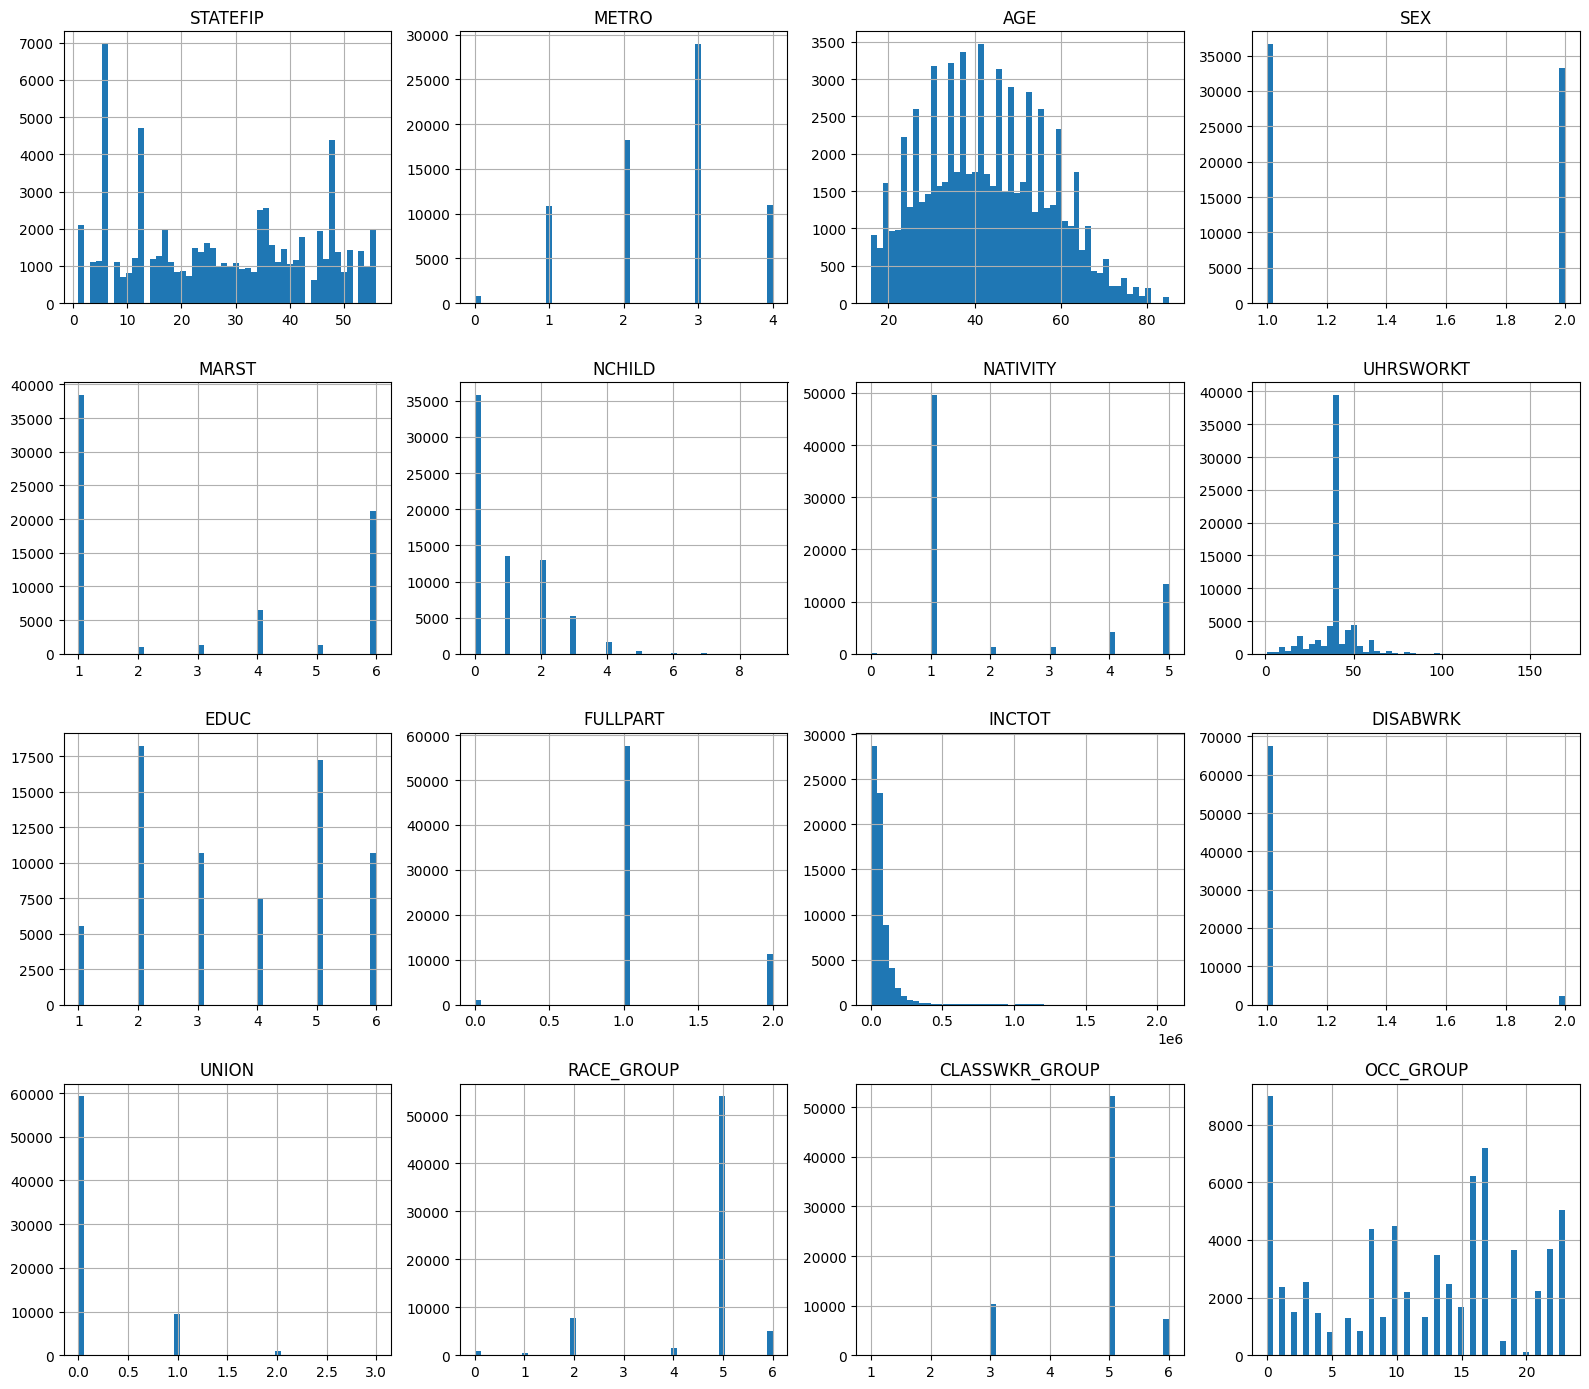

In [142]:
# Graphical: Distribution of every (grouped, numeric) feature
income_df_rm_out_group.hist(bins=50, figsize=(16, 14))
plt.tight_layout()
plt.show()
# Note: AGE and UHRSWORKT are skewed -> QuantileTransformer in Stage 7; INCTOT -> log1p target transform.

## Stage 5 — Feature Engineering

**5a Identification** — split features (X) from target (y). **5b Generation** — build interaction
terms from the continuous drivers. **5c Selection** — rank features with `SelectKBest` and prune
multi-collinear ones via correlation heatmaps.

In [143]:
# Feature Identification (5a): Select Active Dataset Variant for income_X and income_y
# Commented-out blocks show alternative preprocessing paths:
#   - raw income_df:             no grouping
#   - income_df_rm_out_group:    grouped categories, no one-hot
# Active path: fully preprocessed one-hot encoded dataframe
'''
income_X = income_df_rm_out_group.drop(["INCTOT"], axis=1);
income_y = income_df_rm_out_group["INCTOT"].copy();
'''

income_X = income_df_rm_out_group_onehot.drop(["INCTOT"], axis=1);
income_y = income_df_rm_out_group_onehot["INCTOT"].copy();

In [144]:
# Feature Engineering -> Feature Generation (5b): Interaction terms for continuous features
# The 3 continuous drivers that can be combined: AGE, UHRSWORKT, EDUC (ordinal tier)
income_X_feat = income_df_rm_out_group.drop(["INCTOT"], axis=1);
income_X_feat['UHRSWORKTxAGE']  = income_df_rm_out_group['UHRSWORKT'] * income_df_rm_out_group['AGE']
income_X_feat['UHRSWORKTxEDUC'] = income_df_rm_out_group['UHRSWORKT'] * income_df_rm_out_group['EDUC']
income_X_feat['AGExEDUC']       = income_df_rm_out_group['AGE'] * income_df_rm_out_group['EDUC']

# non-linearize (preserved for experimentation)
#income_X_feat['AGE2'] = income_df_rm_out_group['AGE'] ** 2
#income_X_feat['UHRSWORKT2'] = income_df_rm_out_group['UHRSWORKT'] ** 2

# Sanity check for infinities or NaNs introduced by feature generation
indices = np.where(np.isinf(income_X_feat) | np.isnan(income_X_feat))
print("'NaN' or 'inf' indices:", list(zip(*indices)))

'NaN' or 'inf' indices: []


In [145]:
# Textual: Confirm target shape after feature/target split
print(income_y.shape)

(69785,)


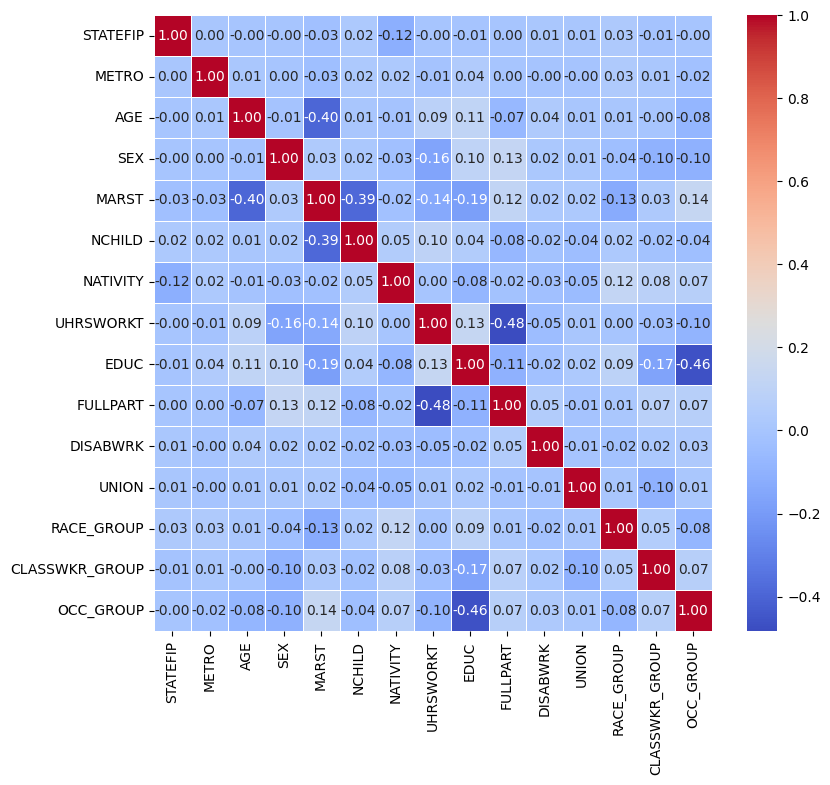

In [146]:
# Graphical: Feature Selection 1 - Pearson correlation heatmap across all grouped features
# High +/-ve correlation to INCTOT -> relevant; near-0 -> weak linear signal
vis_feats_X = income_df_rm_out_group.loc[:, :]
vis_feats_X = vis_feats_X.drop(['INCTOT'], axis=1)
vis_feats_corr = vis_feats_X.corr('pearson')
plt.figure(figsize=(9, 8))
sbn.heatmap(vis_feats_corr, annot=True, linewidths=0.5, fmt='.2f', cmap='coolwarm')
plt.show()

In [147]:
# Feature Engineering -> Feature Selection (5c): SelectKBest with mutual_info_regression (Non-Linear)
# mutual_info_regression: Nonlinear dependence on target; k=10 selects top-10 features
KBest = SelectKBest(score_func=mutual_info_regression, k=10)
output = KBest.fit_transform(income_X_feat, income_y)
top_feats_X = pd.DataFrame(output, columns=KBest.get_feature_names_out())

print(top_feats_X.head())
print(KBest.get_feature_names_out())

    AGE  SEX  MARST  UHRSWORKT  EDUC  FULLPART  OCC_GROUP  UHRSWORKTxAGE  UHRSWORKTxEDUC  AGExEDUC
0  42.0  1.0    6.0       48.0   4.0       1.0        9.0         2016.0           192.0     168.0
1  62.0  1.0    1.0       28.0   2.0       2.0        0.0         1736.0            56.0     124.0
2  64.0  2.0    1.0       40.0   5.0       1.0        6.0         2560.0           200.0     320.0
3  26.0  1.0    1.0       50.0   3.0       1.0       16.0         1300.0           150.0      78.0
4  24.0  2.0    1.0       40.0   3.0       1.0        6.0          960.0           120.0      72.0
['AGE' 'SEX' 'MARST' 'UHRSWORKT' 'EDUC' 'FULLPART' 'OCC_GROUP'
 'UHRSWORKTxAGE' 'UHRSWORKTxEDUC' 'AGExEDUC']


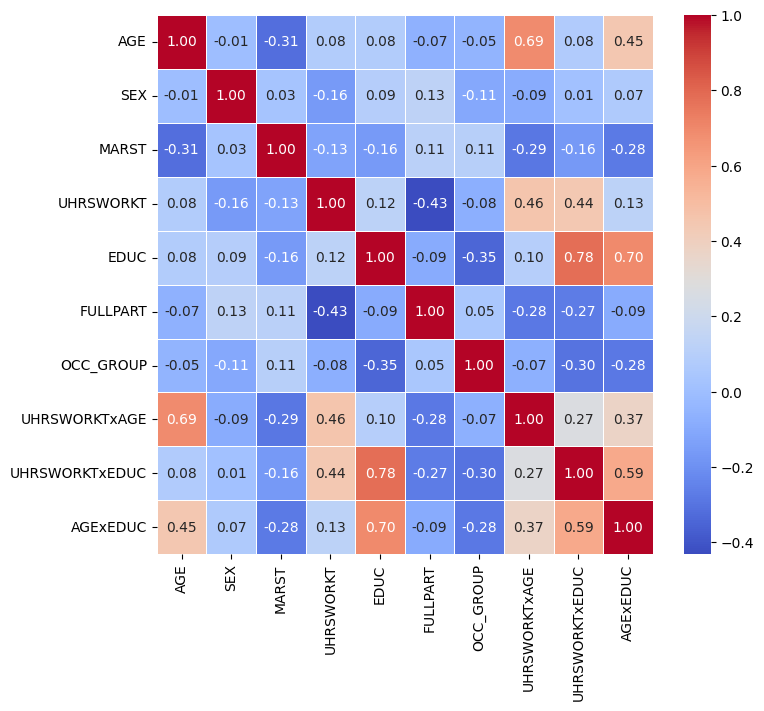

In [148]:
# Graphical: Feature Selection 2 - Kendall correlation heatmap on top-10 selected features
# Kendall (rank): Identifies multi-collinearity/redundancy to eliminate before training
vis_feats_X = top_feats_X.loc[:, :]
vis_feats_corr = vis_feats_X.corr('kendall')
plt.figure(figsize=(8, 7))
sbn.heatmap(vis_feats_corr, annot=True, linewidths=0.5, fmt='.2f', cmap='coolwarm')
plt.show()

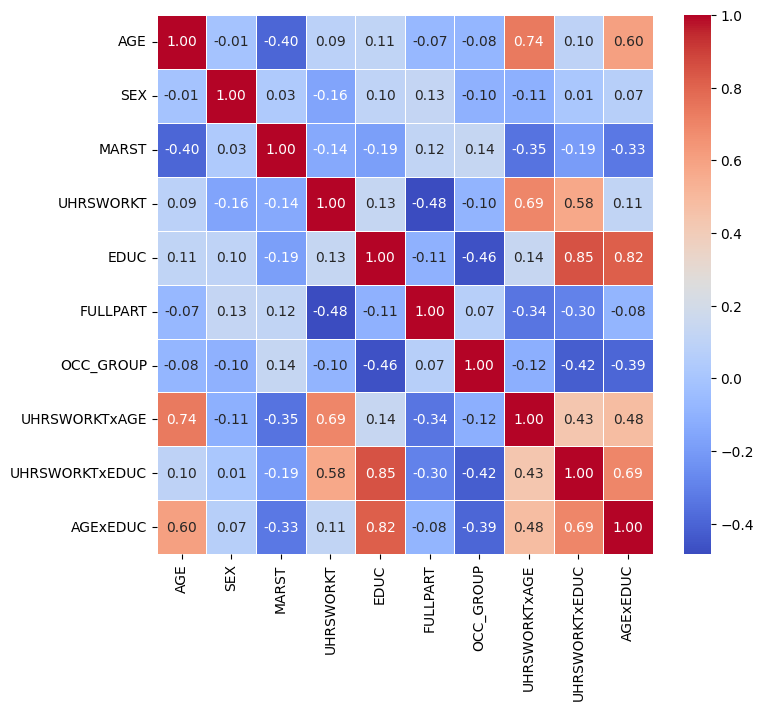

In [149]:
# Graphical: Feature Selection 3 - Pearson correlation heatmap on top-10 selected features
# Pearson (linear): Cross-validates Kendall results for linear multi-collinearity
vis_feats_corr = vis_feats_X.corr('pearson')
plt.figure(figsize=(8, 7))
sbn.heatmap(vis_feats_corr, annot=True, linewidths=0.5, fmt='.2f', cmap='coolwarm')
plt.show()

In [150]:
# Fix Multi-Collinearity: Drop redundant interaction terms that duplicate their parent features.
# UHRSWORKTxAGE is retained (where present) as the most expressive interaction term.
drop_redundant = [c for c in ['UHRSWORKTxEDUC', 'AGExEDUC'] if c in top_feats_X.columns]
top_feats_X.drop(drop_redundant, axis=1, inplace=True)
print("Remaining selected features:", top_feats_X.columns.tolist())

Remaining selected features: ['AGE', 'SEX', 'MARST', 'UHRSWORKT', 'EDUC', 'FULLPART', 'OCC_GROUP', 'UHRSWORKTxAGE']


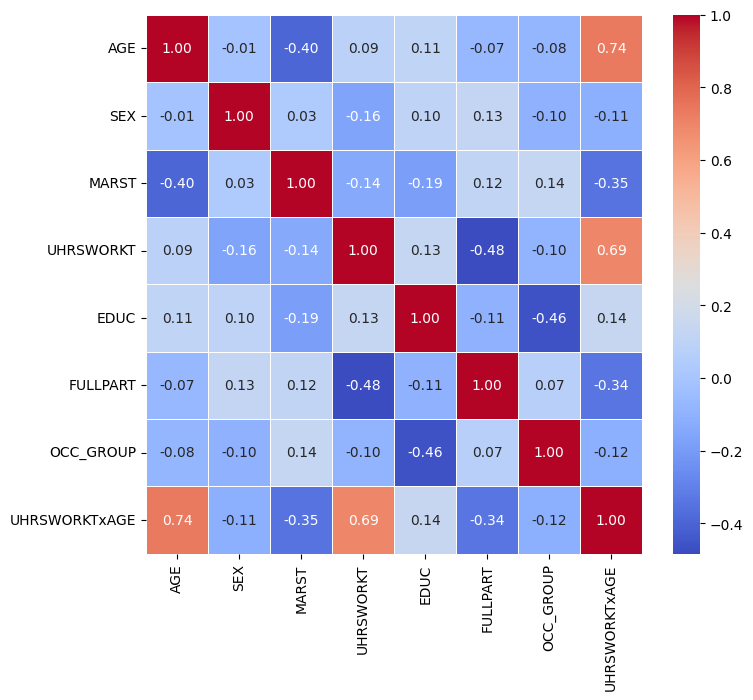

In [151]:
# Graphical: Feature Selection 4 - Pearson heatmap after multi-collinearity removal
# Verify remaining features show low inter-correlation before proceeding to the train/test split
vis_feats_X = top_feats_X.loc[:, :]
vis_feats_corr = vis_feats_X.corr('pearson')
plt.figure(figsize=(8, 7))
sbn.heatmap(vis_feats_corr, annot=True, linewidths=0.5, fmt='.2f', cmap='coolwarm')
plt.show()

## Stage 6 — Train / Test Split

Hold out 20% of the data for final testing. The gradient-boosted models train on the full
one-hot feature matrix (`income_X`); the Stage-5 selection above is exploratory analysis.
After splitting we frequency-encode `STATEFIP` (52 states — too many for one-hot), fitting the
frequency map on **training data only** to avoid leakage.

In [152]:
# Training & Test Sets: ShuffleSplit (80/20 split, random_state=42 for reproducibility)
X = income_X.copy()
y = income_y.copy()

split = ShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in split.split(X):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

In [153]:
# Fix P3e: Frequency-encode STATEFIP (state) - too many classes for ordinal/one-hot
# STATEFIP_freq: proportion of training samples from each state; unseen test values -> 0
# Fit ONLY on data(Train) to avoid 'data-leak' & 'bias' from data(Test)
freq = X_train['STATEFIP'].value_counts(normalize=True)

X_train = X_train.copy()
X_test = X_test.copy()
X_train['STATEFIP_freq'] = X_train['STATEFIP'].map(freq)
X_test['STATEFIP_freq']  = X_test['STATEFIP'].map(freq)

X_test['STATEFIP_freq'] = X_test['STATEFIP_freq'].fillna(0)  # Unseen test categories -> 0

X_train = X_train.drop(columns=['STATEFIP'])
X_test  = X_test.drop(columns=['STATEFIP'])

In [154]:
# Textual: Confirm train/test split shapes before scaling
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(55828, 51) (13957, 51)
(55828,) (13957,)


## Stage 7 — Feature Scaling / Normalisation

Scale the skewed continuous features and the target. The scaler is fit on the **training set only**.
Gradient-boosted trees are scale-invariant, so these scaled frames (`stan_X_*`) are produced for
inspection and for the linear baselines; the `log1p` target transform is the key step that tames
the income skew for every model.

In [155]:
# Feature Scaling: QuantileTransformer on continuous features AGE and UHRSWORKT
# output_distribution='normal': maps skewed age / hours-worked distributions to normal(-1..0..+1)
# Fit ONLY on data(Train) to avoid 'data-leak' & 'bias' from data(Test)
from sklearn.preprocessing import QuantileTransformer
from sklearn.compose import ColumnTransformer

cols_to_transform = ['AGE', 'UHRSWORKT']

quantile_trans = QuantileTransformer(
    output_distribution='normal',
    random_state=42
)
quantile_trans.fit(X_train[cols_to_transform])

stan_X_train = X_train.copy()
stan_X_test = X_test.copy()

# fit on training columns only
stan_X_train[cols_to_transform] = quantile_trans.transform(X_train[cols_to_transform])
stan_X_test[cols_to_transform] = quantile_trans.transform(X_test[cols_to_transform])

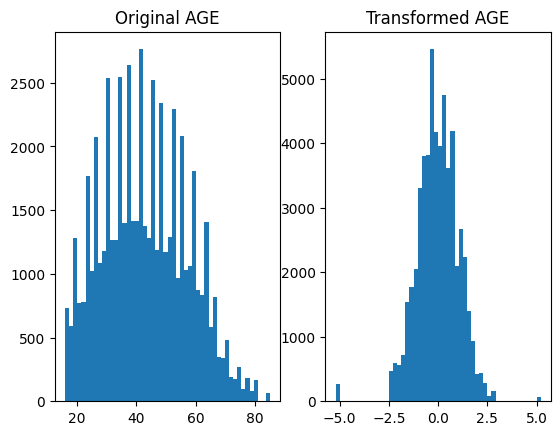

In [156]:
# Graphical: Feature Scaling Verification 1 - AGE distribution before vs. after QuantileTransform
plt.figure()

plt.subplot(1, 2, 1)
plt.hist(X_train['AGE'], bins=50)
plt.title("Original AGE")

plt.subplot(1, 2, 2)
plt.hist(stan_X_train['AGE'], bins=50)
plt.title("Transformed AGE")

plt.show()

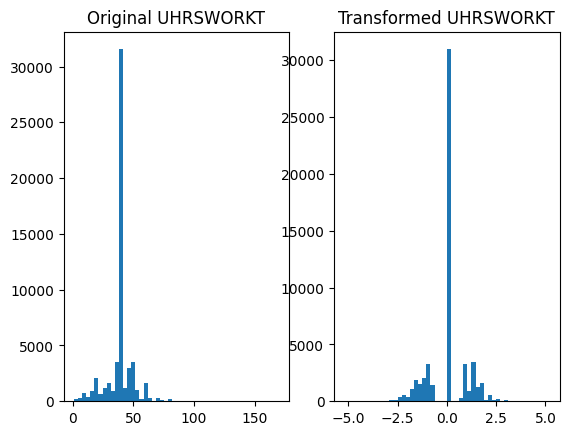

In [157]:
# Graphical: Feature Scaling Verification 2 - UHRSWORKT distribution before vs. after QuantileTransform
plt.figure()

plt.subplot(1, 2, 1)
plt.hist(X_train['UHRSWORKT'], bins=50)
plt.title("Original UHRSWORKT")

plt.subplot(1, 2, 2)
plt.hist(stan_X_train['UHRSWORKT'], bins=50)
plt.title("Transformed UHRSWORKT")

plt.show()

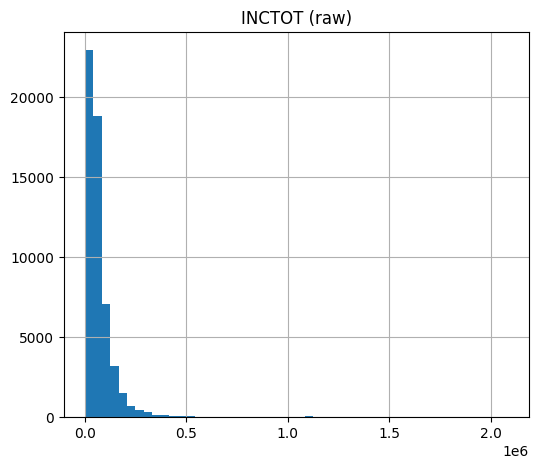

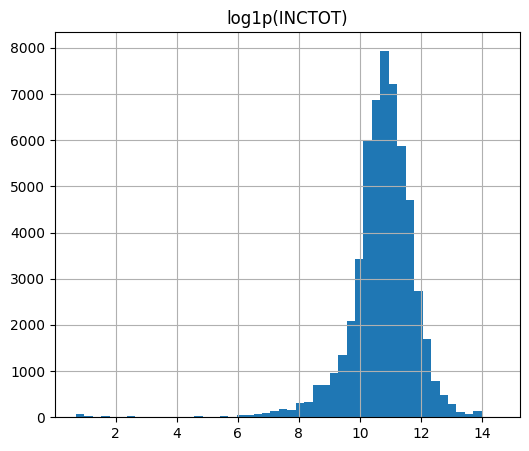

In [158]:
# Target Scaling: Apply log1p transform to INCTOT (handles the heavy right skew of income)
# log1p(y): defined for y >= 0; reverses with expm1() during evaluation
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)
y_train.hist(bins=50, figsize=(6, 5))
plt.title("INCTOT (raw)")
plt.show()
y_train_log.hist(bins=50, figsize=(6, 5))
plt.title("log1p(INCTOT)")
plt.show()

In [159]:
# Target Scaling (alt): Z-Score Standardization (StandardScaler) on INCTOT
# StandardScaler(): transforms target to standard normal distr. (-1..0..+1)
# Fit ONLY on data(Train) to avoid 'data-leak' & 'bias' from data(Test)
stdsc_y_scaler = StandardScaler()
stdsc_y_scaler = stdsc_y_scaler.fit(y_train.values.reshape(-1, 1))
standized_y_train = stdsc_y_scaler.transform(y_train.values.reshape(-1, 1))
standized_y_test = stdsc_y_scaler.transform(y_test.values.reshape(-1, 1))

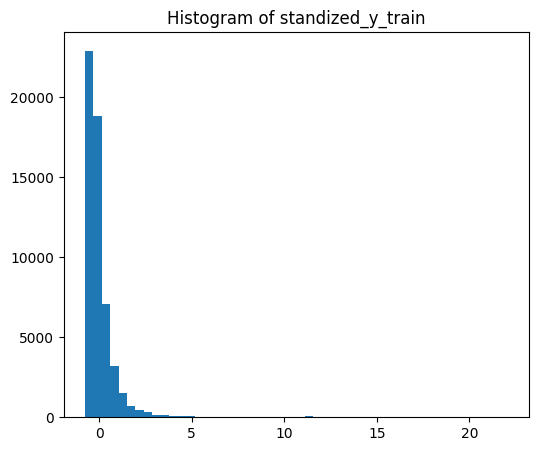

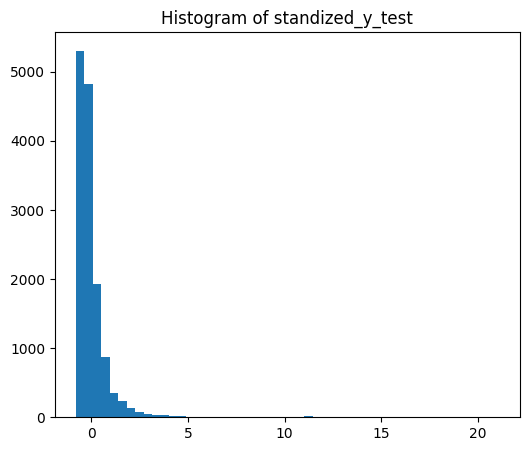

In [160]:
# Graphical: Target Scaling Verification - Histogram of standardized train/test targets
plt.figure(figsize=(6, 5))
plt.hist(standized_y_train, bins=50)
plt.title('Histogram of standized_y_train')
plt.show()

plt.figure(figsize=(6, 5))
plt.hist(standized_y_test, bins=50)
plt.title('Histogram of standized_y_test')
plt.show()

## Stage 8 — Model Selection, Architecture & Compilation

This is a **tabular regression** problem, so we use scikit-learn / gradient-boosting regressors
rather than a deep network. We first benchmark a spread of algorithms (linear baselines + the three
boosting libraries), then commit to an **XGBoost + LightGBM + CatBoost ensemble** for the final model.

In [161]:
# Utility Function: regression_evaluation() - K-Fold Cross-Validation training metrics
# Inverts log1p transform (expm1) before computing MAE, RMSE, R^2 on original dollar scale
# scaler: optional inverse-transform hook for StandardScaler targets
def regression_evaluation(X_train, y_train, algorithm, k, scaler=None):
    y_true = np.asarray(y_train).reshape(-1)
    cv_preds = cross_val_predict(algorithm, X_train, y_true, cv=k, method='predict')
    cv_preds = np.asarray(cv_preds).reshape(-1)

    # If a scaler was used, inverse transform first
    if scaler is not None:
        cv_preds = scaler.inverse_transform(cv_preds.reshape(-1, 1)).reshape(-1)
        y_true = scaler.inverse_transform(y_true.reshape(-1, 1)).reshape(-1)

    # when log applied to target
    cv_preds = np.expm1(cv_preds)
    y_true = np.expm1(y_true)

    print("Prediction shape:", cv_preds.shape)

    mse = mean_squared_error(y_true, cv_preds)
    mae = mean_absolute_error(y_true, cv_preds)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, cv_preds)
    r2 = r2_score(y_true, cv_preds)
    evs = explained_variance_score(y_true, cv_preds)

    #print(f"MSE:  {mse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    #print(f"MAPE: {mape:.4f}")
    print(f"R^2:  {r2:.4f}")
    #print(f"EVS:  {evs:.4f}")

In [162]:
# Utility Function: testing_evaluation() - Final test-set evaluation on held-out data
# Fits model on X_train, predicts on X_test, inverts log1p then reports MAE, RMSE, R^2
# Overfitting(Train ERR << Test ERR); Underfitting(Train ERR >> Test ERR)
def testing_evaluation(X_train, X_test, y_train, y_test, algorithm, scaler=None):
  model = algorithm
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)

  # If a scaler was used, inverse transform first
  if scaler is not None:
      y_pred = scaler.inverse_transform(y_pred.reshape(-1, 1)).reshape(-1)
      y_test = scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1)

  y_pred = np.expm1(y_pred)
  y_test = np.expm1(y_test)

  mse = mean_squared_error(y_test, y_pred)
  mae = mean_absolute_error(y_test, y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_test, y_pred)

  print(f"MAE:  {mae:.4f}")
  print(f"RMSE: {rmse:.4f}")
  print(f"R^2:  {r2:.4f}")

  return model

## Stage 9 — Training

Benchmark candidate algorithms with 3-fold cross-validation on the (log-transformed) training
target, then check their held-out test performance. Cross-validation training error vs. test error
reveals over/under-fitting.

In [163]:
# Training: Baseline Algorithm Sweep via Cross-Validation (k=3)
# Log-transformed target (y_train_log) used; expm1() applied inside regression_evaluation()
algorithms = {
    "Ridge": Ridge(),
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    #"RandomForest": RandomForestRegressor(n_estimators=30, n_jobs=-1, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=50, verbosity=0, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=50, random_state=42, verbose=-1),
    "CatBoost": CatBoostRegressor(iterations=50, verbose=0, random_state=42),
}
for name, alg in algorithms.items():
  print(name, '\n')
  regression_evaluation(X_train, y_train_log, alg, 3)
  print('\n')

Ridge 

Prediction shape: (55828,)
MAE:  34957.5941
RMSE: 83077.4884
R^2:  0.1693


Linear Regression 

Prediction shape: (55828,)
MAE:  34956.8099
RMSE: 83075.7079
R^2:  0.1694


Lasso 

Prediction shape: (55828,)
MAE:  41494.9729
RMSE: 92255.0899
R^2:  -0.0243


XGBoost 

Prediction shape: (55828,)
MAE:  32274.5943
RMSE: 79627.8445
R^2:  0.2369


LightGBM 

Prediction shape: (55828,)
MAE:  32419.4381
RMSE: 80662.9961
R^2:  0.2169


CatBoost 

Prediction shape: (55828,)
MAE:  32404.6492
RMSE: 80240.4350
R^2:  0.2251




In [164]:
# Evaluate: Test-Set Performance of Baseline Algorithms
# Overfitting(Train ERR << Test ERR); Underfitting(Train ERR >> Test ERR)
for name, alg in algorithms.items():
  print(name, '\n')
  testing_evaluation(X_train, X_test, y_train_log, y_test_log, alg)
  print('\n')

Ridge 

MAE:  35156.5615
RMSE: 84556.5524
R^2:  0.1685


Linear Regression 

MAE:  35156.0152
RMSE: 84555.0295
R^2:  0.1685


Lasso 

MAE:  41284.2924
RMSE: 93510.3580
R^2:  -0.0169


XGBoost 

MAE:  32306.3552
RMSE: 81512.0290
R^2:  0.2273


LightGBM 

MAE:  32510.7939
RMSE: 82385.3301
R^2:  0.2107


CatBoost 

MAE:  32368.7044
RMSE: 81817.9151
R^2:  0.2215




## Stage 10 — Ensemble Training with Early Stopping

The template's epoch/callback stage maps here onto **boosting rounds with early stopping**.
Each model trains on `log1p(INCTOT)` against a validation split and stops when the validation
score stops improving (`early_stopping_rounds=100`). The ensemble prediction is the simple
average of the three models.

In [165]:
# Ensemble Training: train_ensemble() - XGBoost, LightGBM, CatBoost with early stopping
# All models trained on log1p(INCTOT); early_stopping_rounds=100 via val_set
# Ensemble prediction = simple average of the three model outputs
def train_ensemble(X_train, y_train_log, X_val, y_val_log):
    """
    Train XGBoost, LightGBM, and CatBoost on log-transformed targets,
    then convert predictions back to original scale for evaluation.
    """
    import numpy as np
    from sklearn.metrics import mean_absolute_error, r2_score

    models = {}
    predictions = {}

    X_train_np = X_train.values if hasattr(X_train, 'values') else X_train
    X_val_np = X_val.values if hasattr(X_val, 'values') else X_val

    y_val = np.expm1(y_val_log)

    # ===== XGBoost Model =====
    print("Training XGBoost...")
    xgb_model = XGBRegressor(
        n_estimators=1200,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=10,
        objective="reg:squarederror",
        tree_method="hist",
        random_state=42,
        verbosity=0,
        early_stopping_rounds=100
    )

    xgb_model.fit(
        X_train_np, y_train_log,
        eval_set=[(X_val_np, y_val_log)],
        verbose=False
    )

    xgb_preds_log = xgb_model.predict(X_val_np)
    xgb_preds = np.expm1(xgb_preds_log)
    xgb_mae = mean_absolute_error(y_val, xgb_preds)
    xgb_r2 = r2_score(y_val, xgb_preds)
    print(f"XGBoost - MAE: {xgb_mae:.4f}, R2: {xgb_r2:.4f}")

    models['xgb'] = xgb_model
    predictions['xgb'] = xgb_preds

    # ===== LightGBM Model =====
    print("Training LightGBM...")
    lgb_model = LGBMRegressor(
        n_estimators=1200,
        learning_rate=0.1,
        max_depth=6,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=10,
        random_state=42,
        verbose=-1
    )

    lgb_model.fit(
        X_train_np, y_train_log,
        eval_set=[(X_val_np, y_val_log)],
        callbacks=[
            lgb.early_stopping(100),
            lgb.log_evaluation(0)
        ]
    )

    lgb_preds_log = lgb_model.predict(X_val_np)
    lgb_preds = np.expm1(lgb_preds_log)
    lgb_mae = mean_absolute_error(y_val, lgb_preds)
    lgb_r2 = r2_score(y_val, lgb_preds)
    print(f"LightGBM - MAE: {lgb_mae:.4f}, R2: {lgb_r2:.4f}")

    models['lgb'] = lgb_model
    predictions['lgb'] = lgb_preds

    # ===== CatBoost Model =====
    print("Training CatBoost...")
    cb_model = CatBoostRegressor(
        iterations=1200,
        learning_rate=0.1,
        depth=6,
        subsample=0.8,
        reg_lambda=10,
        random_state=42,
        verbose=0
    )

    cb_model.fit(
        X_train_np, y_train_log,
        eval_set=[(X_val_np, y_val_log)],
        early_stopping_rounds=100,
        verbose=False
    )

    cb_preds_log = cb_model.predict(X_val_np)
    cb_preds = np.expm1(cb_preds_log)
    cb_mae = mean_absolute_error(y_val, cb_preds)
    cb_r2 = r2_score(y_val, cb_preds)
    print(f"CatBoost - MAE: {cb_mae:.4f}, R2: {cb_r2:.4f}")

    models['catboost'] = cb_model
    predictions['catboost'] = cb_preds

    # ===== Ensemble Predictions =====
    ensemble_preds = (xgb_preds + lgb_preds + cb_preds) / 3
    ensemble_mae = mean_absolute_error(y_val, ensemble_preds)
    ensemble_r2 = r2_score(y_val, ensemble_preds)
    print(f"\nENSEMBLE (Average) - MAE: {ensemble_mae:.4f}, R2: {ensemble_r2:.4f}")
    print(f"Ensemble improvement over best single model: {ensemble_r2 - max(xgb_r2, lgb_r2, cb_r2):.4f} R2 change")

    predictions['ensemble'] = ensemble_preds

    return models, predictions

In [166]:
# Ensemble Evaluation: final_test_evaluation() - Full test-set scoring across all models
# Reports MAE, R^2, RMSE, MAPE on original dollar scale after inverting log1p
# MAPE computed with nonzero_mask to guard against divide-by-zero on zero-income samples
def final_test_evaluation(models_dict, X_train, X_test, y_train_log, y_test_log):
    """
    Evaluates models when target was trained as log1p(y).
    Predictions and y_test are converted back to original dollar scale.
    """

    print("\n" + "="*80)
    print("FINAL TEST SET EVALUATION")
    print("="*80)

    X_test_np = X_test.values if hasattr(X_test, 'values') else X_test

    # Convert y_test back to original scale
    y_test_actual = np.expm1(y_test_log)

    def evaluate_model(model_name, model):
        print(f"Evaluating {model_name} on test set...")

        # Predict in log scale
        preds_log = model.predict(X_test_np)

        # Convert predictions back to original scale
        preds_actual = np.expm1(preds_log)

        mae = mean_absolute_error(y_test_actual, preds_actual)
        r2 = r2_score(y_test_actual, preds_actual)
        rmse = np.sqrt(mean_squared_error(y_test_actual, preds_actual))

        # safer MAPE to avoid divide-by-zero issues
        nonzero_mask = y_test_actual != 0
        mape = np.mean(
            np.abs(
                (y_test_actual[nonzero_mask] - preds_actual[nonzero_mask])
                / y_test_actual[nonzero_mask]
            )
        )

        return preds_actual, mae, r2, rmse, mape

    xgb_preds, xgb_mae, xgb_r2, xgb_rmse, xgb_mape = evaluate_model(
        "XGBoost", models_dict['xgb']
    )

    lgb_preds, lgb_mae, lgb_r2, lgb_rmse, lgb_mape = evaluate_model(
        "LightGBM", models_dict['lgb']
    )

    cb_preds, cb_mae, cb_r2, cb_rmse, cb_mape = evaluate_model(
        "CatBoost", models_dict['catboost']
    )

    print("Evaluating ENSEMBLE on test set...")

    # ensemble in ORIGINAL scale
    ensemble_preds = (xgb_preds + lgb_preds + cb_preds) / 3

    ensemble_mae = mean_absolute_error(y_test_actual, ensemble_preds)
    ensemble_r2 = r2_score(y_test_actual, ensemble_preds)
    ensemble_rmse = np.sqrt(mean_squared_error(y_test_actual, ensemble_preds))

    nonzero_mask = y_test_actual != 0
    ensemble_mape = np.mean(
        np.abs(
            (y_test_actual[nonzero_mask] - ensemble_preds[nonzero_mask])
            / y_test_actual[nonzero_mask]
        )
    )

    test_results = {
        'Model': ['XGBoost', 'LightGBM', 'CatBoost', 'Ensemble'],
        'MAE': [xgb_mae, lgb_mae, cb_mae, ensemble_mae],
        'R2': [xgb_r2, lgb_r2, cb_r2, ensemble_r2],
        'RMSE': [xgb_rmse, lgb_rmse, cb_rmse, ensemble_rmse],
        'MAPE': [xgb_mape, lgb_mape, cb_mape, ensemble_mape]
    }

    summary_df = pd.DataFrame(test_results)

    print("\n" + "="*80)
    print("TEST SET RESULTS - ORIGINAL TARGET SCALE")
    print("="*80)
    print(summary_df.to_string(index=False))
    print("="*80)

    return test_results, summary_df

In [167]:
# Training Ensemble Models: XGBoost, LightGBM, CatBoost on 80/20 train/val split
# models_dict stores trained models; val_predictions stores validation outputs
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train_log, test_size=0.2, random_state=42)

models_dict, val_predictions = train_ensemble(X_tr, y_tr, X_val, y_val)

Training XGBoost...
XGBoost - MAE: 31509.8340, R2: 0.2497
Training LightGBM...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[187]	valid_0's l2: 0.631672
LightGBM - MAE: 31475.9172, R2: 0.2500
Training CatBoost...


c:\Users\Jonathan\Documents\School\CSC 180\Project_Echo2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


CatBoost - MAE: 31579.5300, R2: 0.2411

ENSEMBLE (Average) - MAE: 31451.5195, R2: 0.2480
Ensemble improvement over best single model: -0.0020 R2 change


## Stage 11 — Evaluation on Test Set & Learning Curves

Score the trained ensemble (and each member) on the untouched test set, then visualise the
comparison. For this tabular boosting model the four-panel bar chart of MAE / R² / RMSE / MAPE
plays the role the accuracy/loss learning curves play for a deep network.

In [168]:
# Evaluate: Final Test-Set Results for Ensemble and Individual Models
# Overfitting(Train ERR << Test ERR); Underfitting(Train ERR >> Test ERR)
test_results_final, summary_table = final_test_evaluation(
    models_dict, X_tr, X_test, y_tr, y_test_log
)


FINAL TEST SET EVALUATION
Evaluating XGBoost on test set...
Evaluating LightGBM on test set...
Evaluating CatBoost on test set...
Evaluating ENSEMBLE on test set...

TEST SET RESULTS - ORIGINAL TARGET SCALE
   Model          MAE       R2         RMSE      MAPE
 XGBoost 32148.998450 0.227908 81480.412774 11.814926
LightGBM 32146.331732 0.230226 81358.013832 10.913713
CatBoost 32280.086673 0.222754 81751.951232 11.463955
Ensemble 32109.340654 0.228003 81475.399311 11.395820


c:\Users\Jonathan\Documents\School\CSC 180\Project_Echo2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


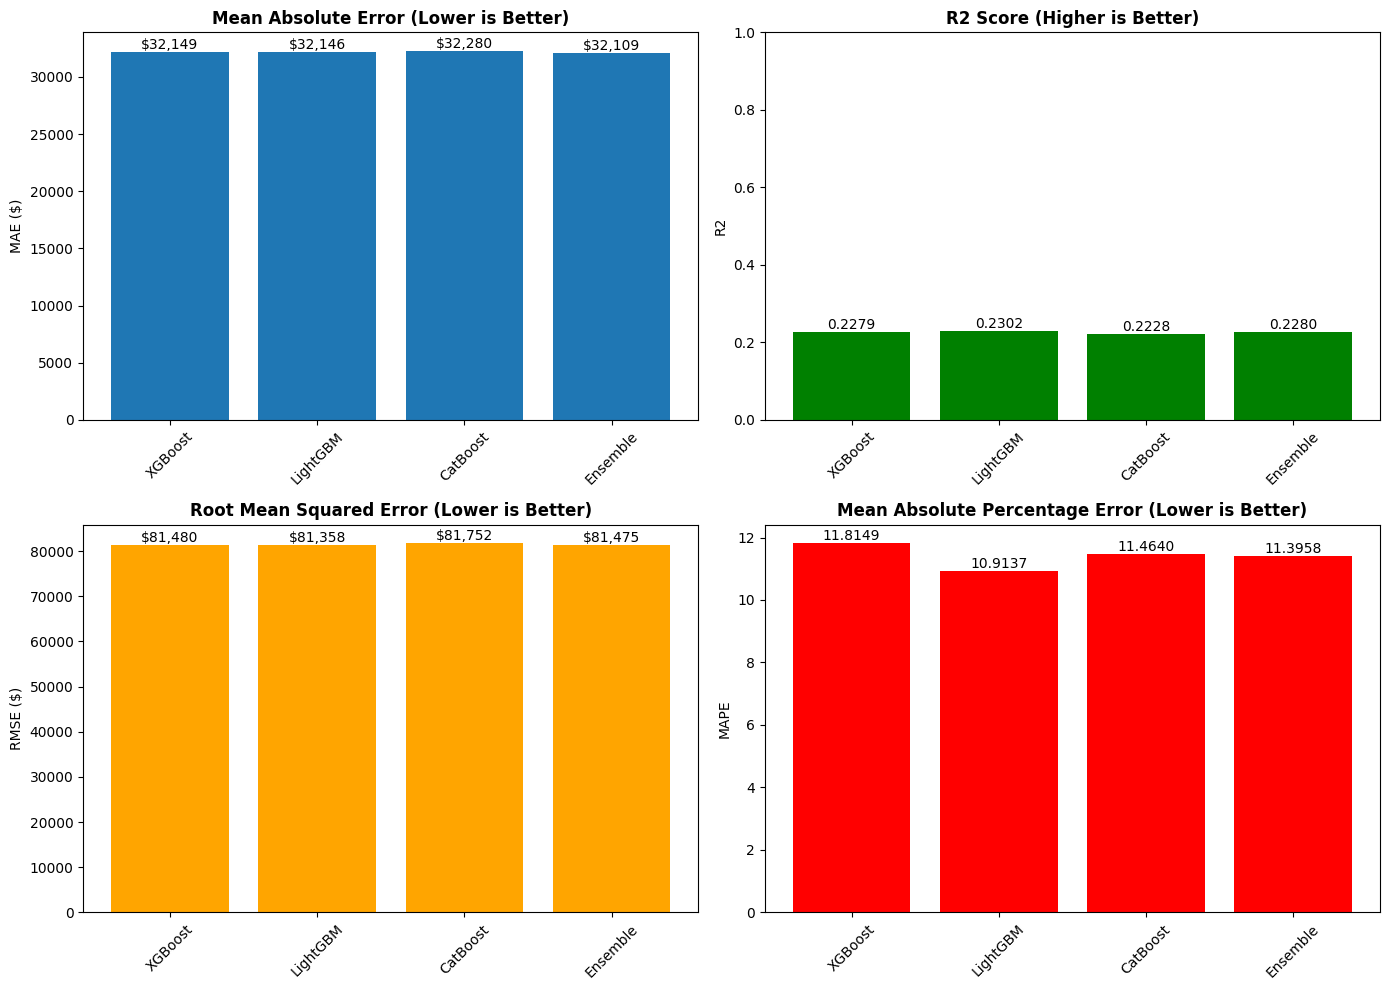

Model performance comparison chart displayed


In [169]:
# Learning Curve (tabular): compare ensemble members on MAE, R^2, RMSE, MAPE
# 4-panel bar chart comparing XGBoost, LightGBM, CatBoost, and Ensemble on the test set
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: MAE Comparison
axes[0, 0].bar(summary_table['Model'], summary_table['MAE'])
axes[0, 0].set_title('Mean Absolute Error (Lower is Better)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('MAE ($)')
axes[0, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(summary_table['MAE']):
    axes[0, 0].text(i, v, f'${v:,.0f}', ha='center', va='bottom')

# Plot 2: R^2 Comparison
axes[0, 1].bar(summary_table['Model'], summary_table['R2'], color='green')
axes[0, 1].set_title('R2 Score (Higher is Better)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('R2')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].tick_params(axis='x', rotation=45)
for i, v in enumerate(summary_table['R2']):
    axes[0, 1].text(i, v, f'{v:.4f}', ha='center', va='bottom')

# Plot 3: RMSE Comparison
axes[1, 0].bar(summary_table['Model'], summary_table['RMSE'], color='orange')
axes[1, 0].set_title('Root Mean Squared Error (Lower is Better)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('RMSE ($)')
axes[1, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(summary_table['RMSE']):
    axes[1, 0].text(i, v, f'${v:,.0f}', ha='center', va='bottom')

# Plot 4: MAPE Comparison
axes[1, 1].bar(summary_table['Model'], summary_table['MAPE'], color='red')
axes[1, 1].set_title('Mean Absolute Percentage Error (Lower is Better)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('MAPE')
axes[1, 1].tick_params(axis='x', rotation=45)
for i, v in enumerate(summary_table['MAPE']):
    axes[1, 1].text(i, v, f'{v:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("Model performance comparison chart displayed")

## Stage 12 — Model Saving & Inference

Persist the trained models together with **every preprocessing artifact** needed to transform a
raw record at inference time: the KNN imputer, the ordinal encoders, the `STATEFIP` frequency map,
the quantile transformer, and the final feature-column order. Then reload and run a sample
prediction to confirm the saved pipeline reproduces the model's outputs.

In [170]:
# Save Model Pipeline: Persist trained models and all preprocessing encoders via joblib
# Artifact contains: models dict, imputer, scalers, ordinal encoders, frequency map, feature columns
# Load with: artifact = joblib.load('income_pipeline.pkl')
import joblib

artifact = {
    "models": models_dict,
    "knn_imputer": knn_imputer,                     # imputes UHRSWORKT from AGE/UHRSWORKT/EDUC
    "cols_to_transform": cols_to_transform,         # AGE, UHRSWORKT -> QuantileTransformer
    "quantile_transformer": quantile_trans,
    "classwkr_ordinal_encoder": ordinal_classwkr,
    "race_ordinal_encoder": ordinal_race,
    "occ_ordinal_encoder": ordinal,
    "statefip_frequency_map": freq,                 # frequency map for STATEFIP; apply before predict()
    "feature_columns": X_train.columns.tolist(),
    "classwkr_categories": ordinal_classwkr.categories_,
    "race_categories": race_order,
    "occ_categories": ordinal.categories_,
    "target": "INCTOT",
    "target_transform": "log1p / expm1",
}
joblib.dump(artifact, "income_pipeline.pkl")
print("Saved income_pipeline.pkl with keys:", list(artifact.keys()))

Saved income_pipeline.pkl with keys: ['models', 'knn_imputer', 'cols_to_transform', 'quantile_transformer', 'classwkr_ordinal_encoder', 'race_ordinal_encoder', 'occ_ordinal_encoder', 'statefip_frequency_map', 'feature_columns', 'classwkr_categories', 'race_categories', 'occ_categories', 'target', 'target_transform']


In [171]:
# Inference Demo: reload the saved pipeline and predict on a sample of the held-out test set
artifact = joblib.load("income_pipeline.pkl")
loaded_models = artifact["models"]

sample_X = X_test.iloc[:10]
sample_truth = np.expm1(y_test_log.iloc[:10].values)

# Ensemble = average of the three boosters, inverted from log scale
pred_log = np.mean([m.predict(sample_X.values) for m in
                    [loaded_models['xgb'], loaded_models['lgb'], loaded_models['catboost']]], axis=0)
pred_dollars = np.expm1(pred_log)

compare = pd.DataFrame({
    "Predicted ($)": np.round(pred_dollars).astype(int),
    "Actual ($)":    np.round(sample_truth).astype(int),
})
print(compare.to_string(index=False))

 Predicted ($)  Actual ($)
         33498       40000
         24694       16206
         32675       17000
         23486       56536
         49348       46100
         31684       27001
         39034       47355
         45085       25000
         45212       76205
         36094       45000


c:\Users\Jonathan\Documents\School\CSC 180\Project_Echo2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## Quick-Reference: Stage Sequence

| Stage | Name | Key Concern (CPS edition) |
|-------|------|---------------------------|
| 1 | Environment Setup | Imports & display options |
| 2 | Data Loading & Preview | Fixed-width parse via DDI codebook |
| 3 | Data Cleaning | Sentinel codes → population filter → KNN impute → grouping/encoding |
| 4 | Graphical EDA | Feature distributions & skew |
| 5 | Feature Engineering | Interactions → SelectKBest → de-collinearise |
| 6 | Train / Test Split | 80/20 + STATEFIP frequency encoding (no leakage) |
| 7 | Feature Scaling | QuantileTransformer (X) + log1p (y), fit on train only |
| 8 | Model Selection | Linear baselines + XGB/LGBM/CatBoost ensemble |
| 9 | Training | 3-fold CV sweep + test comparison |
| 10 | Ensemble Training | Boosting rounds with early stopping |
| 11 | Evaluation | Test metrics + comparison chart |
| 12 | Save & Inference | joblib artifact + reload demo |

*Data: IPUMS CPS ASEC 2022 extract `cps_00001.dat`, codebook `cps_00001.xml`. Target: `INCTOT` (total personal income).*